# PC. 06)

Desenvolver um modelo de classificação binária para detectar áreas com desmatamento ativo, usando imagens de satélite e variáveis ambientais como entrada. No entanto, o conjunto de dados apresenta alto desbalanceamento: apenas 5% das amostras representam desmatamento, enquanto os outros 95% correspondem a áreas preservadas. Simule ou carregue um conjunto de dados desbalanceado, com:

- Atributos numéricos ou derivados de imagens (podem ser sintéticos);
- Uma variável binária: 1 = desmatado, 0 = preservado.

Treine um modelo de classificação binária (MLP) e compare o desempenho usando:

- K-Fold comum (sem estratificação) e;
- Stratified K-Fold.

Ao final, discorra sobre as abordagens K-Fold tradicional e K-Fold estratificado. Em que situações a estratificação se torna fundamental? Considerando a importância da aplicação, quais as vantagens em utilizar a estratégia leave-one-out? A utilização dessa técnica é viável, considerando o tamanho do conjunto de dados? Fale sobre o custo computacional dessa estratégia de validação.

In [1]:
!pip install scikit-learn

In [3]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Definição de métodos auxiliares:

In [118]:
def normalize(X, method="zscore"):
    if method == "zscore":
        mean = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        std[std == 0] = 1
        return (X - mean) / std, mean, std
    
    elif method == "minmax":
        X_min = np.min(X, axis=0)
        X_max = np.max(X, axis=0)
        denom = X_max - X_min
        denom[denom == 0] = 1
        return (X - X_min) / denom, X_min, X_max

def overview_dataset(x, y, dimensions=[], title="Dataset"):
    dim0, dim1 = dimensions

    classes = np.unique(y)

    for c in classes:
        idx = np.where(y == c)
        plt.scatter(
            x[idx, dim0],
            x[idx, dim1],
            label=f"Classe {c}"
        )

    plt.title(title)
    plt.xlabel(f"Feature {dim0}")
    plt.ylabel(f"Feature {dim1}")
    plt.legend()
    plt.show()

def plot_distribution(y):
    # Contar amostras por classe
    class_counts = pd.Series(y).value_counts().sort_index()
    
    # Labels (nomes das classes)
    labels = [ f'class_{n}' for n in list(set(y))]
    
    # Plotar gráfico de pizza
    plt.figure()
    plt.pie(class_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Distribuição das Classes')
    
    plt.show()

# Forçar desbalanço
def force_desbalance(X, y, props = {}):
    classes = np.unique(y)
    indices = {c: np.where(y == c)[0] for c in classes}
    
    n_total = len(y)
    new_indices = []    
    for c in classes:
        n_samples = int(props[c] * n_total)
        sampled = np.random.choice(indices[c], size=n_samples, replace=True)
        new_indices.extend(sampled)
        
    return X[new_indices], y[new_indices]

# Definição do Kfold:

In [31]:
class Kfold:

    def __init__(self, k=5, shuffle=True, random_state = 42):
        self.k = k
        self.shuffle = shuffle
        self.random_state = random_state

    def shuffle_data(self, X, y):
        indices = np.arange(X.shape[0])
        np.random.seed(self.random_state)
        np.random.shuffle(indices)
        return X[indices], y[indices]
    
    def get_folds(self, X, y):
        if self.shuffle:
          X, y = self.shuffle_data(X, y)
        fold_size = X.shape[0] // self.k
        
        folds = {}
        
        for i in range(self.k):
          start = i * fold_size
          end = start + fold_size
        
          X_val = X[start:end]
          y_val = y[start:end]
        
          X_train = np.concatenate([X[:start], X[end:]])
          y_train = np.concatenate([y[:start], y[end:]])
        
          folds[i] = {
              "X_train": X_train,
              "y_train": y_train,
              "X_val": X_val,
              "y_val": y_val
          }
        
        return folds

    def get_stratified_folds(self, X, y):
        if self.shuffle:
            X, y = self.shuffle_data(X, y)
    
        folds = {i: {"X_train": [], "y_train": [], "X_val": [], "y_val": []} for i in range(self.k)}

        for class_ in np.unique(y):
            class_idx = np.where(y == class_)[0]
            X_class = X[class_idx]
            y_class = y[class_idx]
            fold_size = X_class.shape[0] // self.k
    
            for i in range(self.k):
                start = i * fold_size
                end = start + fold_size
                
                X_val = X_class[start:end]
                y_val = y_class[start:end]
    
                X_train = np.concatenate([X_class[:start], X_class[end:]])
                y_train = np.concatenate([y_class[:start], y_class[end:]])
    
                folds[i]["X_train"].append(X_train)
                folds[i]["y_train"].append(y_train)
                folds[i]["X_val"].append(X_val)
                folds[i]["y_val"].append(y_val)
    
        # juntar todas as classes em cada fold
        for i in range(self.k):
            folds[i]["X_train"] = np.concatenate(folds[i]["X_train"])
            folds[i]["y_train"] = np.concatenate(folds[i]["y_train"])
            folds[i]["X_val"] = np.concatenate(folds[i]["X_val"])
            folds[i]["y_val"] = np.concatenate(folds[i]["y_val"])

        return folds

    def plot_folds_distribution(self, folds, type_ = ""):
        k = len(folds)
    
        train_class0 = []
        train_class1 = []
        val_class0 = []
        val_class1 = []
    
        for i in range(k):
            y_train = folds[i]["y_train"]
            y_val = folds[i]["y_val"]
    
            train_counts = Counter(y_train)
            val_counts = Counter(y_val)
    
            total_train = len(y_train)
            total_val = len(y_val)
    
            train_class0.append(train_counts.get(0, 0) / total_train)
            train_class1.append(train_counts.get(1, 0) / total_train)
    
            val_class0.append(val_counts.get(0, 0) / total_val)
            val_class1.append(val_counts.get(1, 0) / total_val)
    
        x = np.arange(k)
    
        # ---- TRAIN ----
        plt.figure()
        bars_c0 = plt.bar(x, train_class0, label='Class 0')
        bars_c1 = plt.bar(x, train_class1, bottom=train_class0, label='Class 1')
    
        # labels
        for i in range(k):
            # class 0
            if train_class0[i] > 0:
                plt.text(
                    x[i],
                    train_class0[i] / 2,
                    f"{train_class0[i]*100:.0f}%",
                    ha='center',
                    va='center'
                )
            # class 1
            if train_class1[i] > 0:
                plt.text(
                    x[i],
                    train_class0[i] + train_class1[i] / 2,
                    f"{train_class1[i]*100:.0f}%",
                    ha='center',
                    va='center'
                )
    
        plt.ylim(0, 1)
        plt.xticks(x, [f"Fold {i}" for i in range(k)])
        plt.title(f"TRAIN - proporção por classe {type_}")
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # 👈 legenda fora
        plt.tight_layout()
        plt.show()
    
        # ---- VALIDATION ----
        plt.figure()
        bars_c0 = plt.bar(x, val_class0, label='Class 0')
        bars_c1 = plt.bar(x, val_class1, bottom=val_class0, label='Class 1')
    
        # labels
        for i in range(k):
            if val_class0[i] > 0:
                plt.text(
                    x[i],
                    val_class0[i] / 2,
                    f"{val_class0[i]*100:.0f}%",
                    ha='center',
                    va='center'
                )
            if val_class1[i] > 0:
                plt.text(
                    x[i],
                    val_class0[i] + val_class1[i] / 2,
                    f"{val_class1[i]*100:.0f}%",
                    ha='center',
                    va='center'
                )
    
        plt.ylim(0, 1)
        plt.xticks(x, [f"Fold {i}" for i in range(k)])
        plt.title(f"VALIDATION - proporção por classe {type_}")
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # 👈 legenda fora
        plt.tight_layout()
        plt.show()

## Definição da MLP:

In [117]:
# Basic models used to build a multilayer perceptron that
# uses a backpropagation algorithm to learn from data.
#
# Author: Prof. Fabrício Galende Marques de Carvalho
#
class Neuron:
    """ 
    Basic neuron model used to build a single
    processing unit.
    """
    def __init__(self, act_func, d_act_func, pre_act=0, post_act=0):
        self.activation_function = act_func
        self.activation_function_derivative = d_act_func
        self.pre_activation = pre_act
        self.post_activation = post_act

    def process(self,v):
        self.pre_activation = v
        self.post_activation = self.activation_function(v)
        return self.post_activation

    def process_d(self):
        return self.activation_function_derivative(self.pre_activation)

class Layer:
    """
    Model for a single processing Layer.
    Once a layer is created, an additional input is always created
    to include bias.
    """
    def __init__( self, dimension, neuron_model, act_func, d_act_func ):
        """
        dimension: number of neurons in the layer
        No initial condition is passed to neurons. To change it, each
        neuron must be accessed through self.neurons array.
        """
        self.dimension = dimension
        self.neuron_model = neuron_model
        self.neurons = np.empty(dimension, dtype=object)
        self.pre_activation = np.zeros((dimension,1))
        self.post_activation = np.zeros((dimension,1))
        self.local_derivatives = np.zeros((dimension,1))
        for neuron_index in range(dimension):
            self.neurons[neuron_index] = neuron_model(act_func, d_act_func)   

    def process(self, v, learn=False):
        """
        v is the vector (dimension x1), which corresponds
        to the local field for each neuron
        """
        self.pre_activation = np.array(v).reshape(-1,1) ## reshape(-1,1) -> any number of lines and only one column
        output = []
        deriv = []
        for i,neuron in enumerate(self.neurons):
            output.append(neuron.process(v[i]))
            if learn:
                deriv.append(neuron.process_d())
        self.post_activation = np.array(output).reshape(-1,1)
        if learn:
            self.local_derivatives = np.array(deriv).reshape(-1,1)
        return np.array(output).reshape(-1,1)

    def process_d(self):
        output = []
        for neuron in self.neurons:
            output.append(neuron.process_d()[0])
        self.local_derivatives = np.array(output).reshape(-1,1)
        return self.local_derivatives

class FFNeuralNetwork:
    """
      A class that models a feedforward neural network
    """
    def __init__(self, topology, layers, W0 = None, zero_init = False, rand_seed = 0):
        """
         topology: array that contains the number of neurons
         per layer, including input layer (i.e., a network
         with topology [3,2,1] contains three inputs, 2 
         neurons in the hidden layer and one output layer.
        """
        self.topology = topology        # defines a dense feedforward NN
        self.n_layers = len(topology)-1 # number of processing layers
        self.layers = layers
        self.weights = W0
        self.e_epochs = []
        self.mse_epochs = []
        self.fold_errors = []
        if self.weights is None: # no initialization was provided
            self.weights = []
            if not zero_init: #random initialization is performed
                np.random.seed(rand_seed)
                for i in range(len(topology)-1):
                    #negative and positive initial weights: 
                    self.weights.append(np.random.uniform(low=-1.0, high=1.0, size=(self.topology[i+1], self.topology[i] + 1))) 
                    # only positive initial weights:
                    # self.weights.append(np.random.rand(self.topology[i+1],self.topology[i]+1)) ## bias is taken into account here
            else:
                for i in range(len(topology)-1):
                    self.weights.append(np.zeros((self.topology[i+1],self.topology[i]+1))) ## bias is taken into account here

    def process(self, x, learn=False):
        """
        Performs the forward propagation and gets neural network output from
        vector input x
        """
        for i, layer in enumerate(self.layers):
            if i == 0:
                x_in = np.vstack( (x,[[1]] )) # here we stack the bias input for the first layer 
            else:
                x_in = np.vstack( [self.layers[i-1].post_activation, [[1]]]) 
            v = self.weights[i] @ x_in
            layer.process(v, learn)
        return self.layers[self.n_layers-1].post_activation

    def backprop(self, x, y_d, eta):
        """
        Here we implement the backpropagation algorithm.
        It is assumed that x and y_d are both column vectors and 
        it is also assumed that the layers were appropriately
        initialized.

        This algorithm is implemented for a single example learning 
        and it can be easily wrapped in a version that is applicable
        to some training set.

        eta: learning rate
        """

        # First we propagate through the network
        output = self.process(x, learn=True)
        # Then we compute the output error vector
        error_vector = y_d - output

        # Now we compute the gradients for the output and hidden layers, in
        # reverse order
        grad_indices = list(range(self.n_layers))
        grad_indices.reverse()
        local_grads = []
        for i in range(self.n_layers):
            local_grads.append(np.zeros((self.topology[i+1],1)))
        for l_idx in grad_indices:
            if l_idx == (self.n_layers - 1) : #output layer
                 #local gradient for the output layer
                 delta_k = error_vector * self.layers[self.n_layers-1].local_derivatives  #element-wise operation
                 local_grads[l_idx] = delta_k
            else:                 
                # delta_k_1 = phi'(v_k_1) *  (W_k^T. delta_k ) 
                delta_k_1 =  self.layers[l_idx].local_derivatives * (self.weights[(l_idx + 1)][:, :-1].T @ local_grads[(l_idx+1)] )
                local_grads[l_idx] = delta_k_1
        # now we can compute the appropriate weight corrections:
        for i in range(self.n_layers):
            if i == 0: #input layer
                self.weights[i] = self.weights[i] + eta * local_grads[i] @ np.vstack((x,[[1]])).T
            else:
                self.weights[i] = self.weights[i] + eta * local_grads[i] @ np.vstack( (self.layers[i-1].post_activation, [[1]])).T
        #Return the error just to measure the training process effectiveness:
        return error_vector

    def fit(self, x, y, learning_rate = 0.05, n_epochs = 500):
        self.e_epochs = []
        self.mse_epochs = []
        indices = list(range(len(x)))
    
        for epoch in range(n_epochs):
            e_point = []
            e_sum = 0
            np.random.shuffle(indices)
            
            for k in indices:
                x_i = x[k].reshape(-1,1)   # ✅ agora correto
                y_i = y[k].reshape(-1,1)
                
                error = self.backprop(x_i, y_i, learning_rate)
                err_val = error[0][0]
                e_sum += error[0][0]**2
                e_point.append(err_val)
            
            self.e_epochs.append(np.mean(np.abs(e_point)))
            self.mse_epochs.append(e_sum / len(x))
            
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Erro: {self.e_epochs[-1]}")
    
        return self

    def fit_by_folds(self, folds, learning_rate=0.05, n_epochs=500, threshold = 0.5):
        self.fold_errors = []
        self.fold_mse = []
        self.fold_accuracies = []
    
        # salva pesos iniciais
        initial_weights = [w.copy() for w in self.weights]
    
        for fold_idx in folds:
            print(f"\n=== Fold {fold_idx} ===")
    
            X_train = folds[fold_idx]["X_train"]
            y_train = folds[fold_idx]["y_train"]
            X_val = folds[fold_idx]["X_val"]
            y_val = folds[fold_idx]["y_val"]
    
            # NORMALIZA (usando apenas treino)
            mean = np.mean(X_train, axis=0)
            std = np.std(X_train, axis=0)
            std[std == 0] = 1
    
            X_train_norm = (X_train - mean) / std
            X_val_norm = (X_val - mean) / std
    
            # RESET dos pesos
            self.weights = [w.copy() for w in initial_weights]
    
            # TREINO
            self.fit(X_train_norm, y_train, learning_rate, n_epochs)
    
            # VALIDAÇÃO
            errors = []
            squared_errors = []
            y_preds = []
    
            for i in range(len(X_val_norm)):
                x_i = X_val_norm[i].reshape(-1,1)
                y_true = y_val[i]
    
                y_pred = self.process(x_i)[0][0]
    
                # erro contínuo
                error = y_true - y_pred
                errors.append(abs(error))
                squared_errors.append(error**2)
    
                # classificação (threshold)
                pred_class = 1 if y_pred >= threshold else 0
                y_preds.append(pred_class)
    
            # métricas
            mean_error = np.mean(errors)
            mse = np.mean(squared_errors)
            acc = np.mean(np.array(y_preds) == y_val)
    
            self.fold_errors.append(mean_error)
            self.fold_mse.append(mse)
            self.fold_accuracies.append(acc)
    
            print(f"Erro médio (val): {mean_error:.4f}")
            print(f"MSE (val): {mse:.4f}")
            print(f"Acurácia (val): {acc:.4f}")
    
        print("\n=== Resultado Final ===")
        print(f"Erro médio geral: {np.mean(self.fold_errors):.4f}")
        print(f"MSE médio: {np.mean(self.fold_mse):.4f}")
        print(f"Acurácia média: {np.mean(self.fold_accuracies):.4f}")

        return self

    def plot_error(self):
        plt.plot(self.e_epochs, color="black")
        plt.title("Erro médio de classificação")
        plt.xlabel("Época de treinamento")
        plt.ylabel("Erro")
        plt.grid()
        plt.show()

    def plot_mse(self):
        plt.figure()
        plt.plot(self.mse_epochs, color="black")
        plt.title("Erro Quadrático Médio (MSE)")
        plt.xlabel("Época de treinamento")
        plt.ylabel("MSE")
        plt.grid()
        plt.show()

    def plot_errors_by_folds(self):
        plt.figure()
        x = np.arange(1, len(self.fold_mse) + 1) 
        plt.plot(x, self.fold_errors, marker='o')
        plt.xticks(x)        
        plt.title("Erro por fold")
        plt.xlabel("Fold")
        plt.ylabel("Erro médio")
        plt.grid()
        plt.show()

    def plot_mse_by_folds(self):
        plt.figure()
        x = np.arange(1, len(self.fold_mse) + 1) 
        plt.plot(x, self.fold_mse, marker='o')
        plt.xticks(x)
        plt.title("MSE por fold")
        plt.xlabel("Fold")
        plt.ylabel("MSE médio")
        plt.grid()
        plt.show()

    def plot_accuracy_by_folds(self):
        plt.figure()
        x = np.arange(1, len(self.fold_mse) + 1) 
        plt.plot(x, self.fold_accuracies, marker='o')
        plt.xticks(x)
        plt.title("Acurácia por fold")
        plt.xlabel("Fold")
        plt.ylabel("Acurácia média")
        plt.ylim(0, 1)
        plt.grid()
        plt.show()

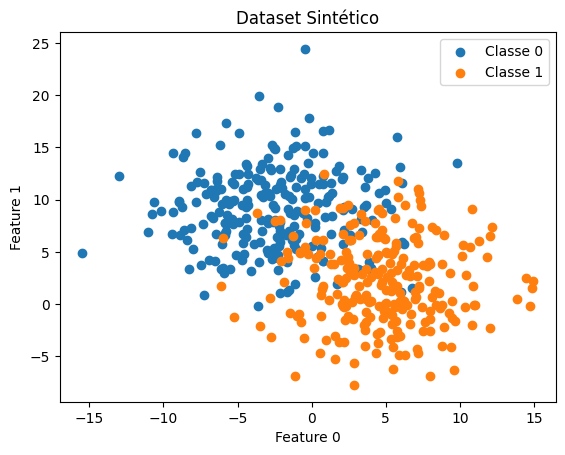

In [125]:
X, y = make_blobs(
    n_samples=500,
    centers=2,
    cluster_std=4,
    random_state=42
)
overview_dataset(X, y, [0,1], "Dataset Sintético")

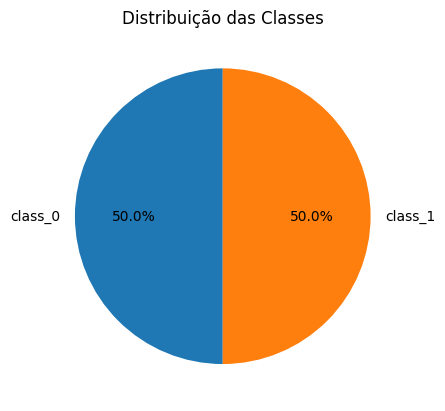

In [113]:
plot_distribution(y)

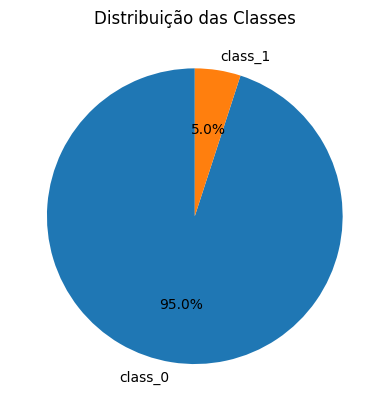

In [114]:
X_bal, y_bal = force_desbalance(X, y, props = {0: 0.95, 1: 0.05})
plot_distribution(y_bal)

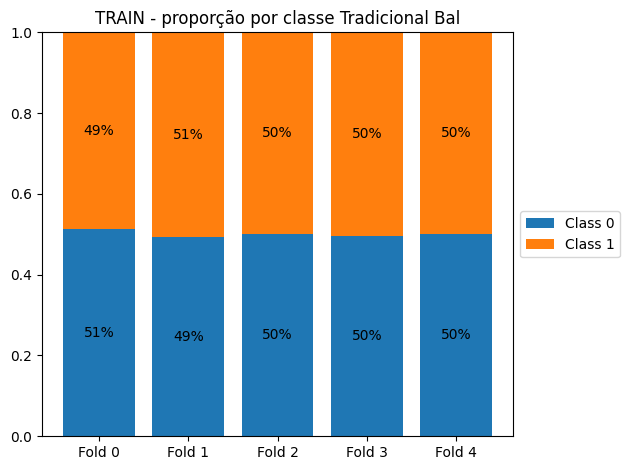

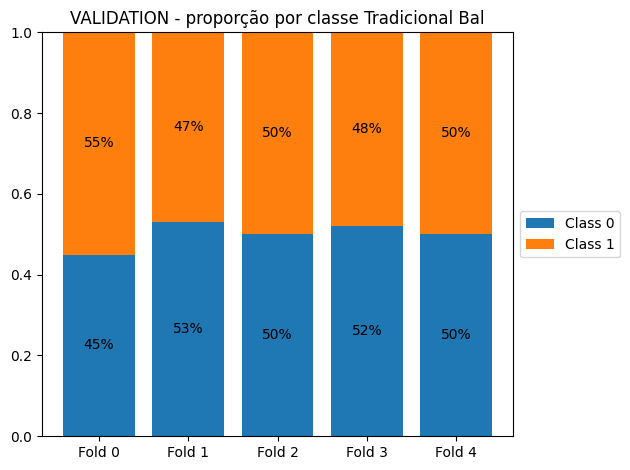

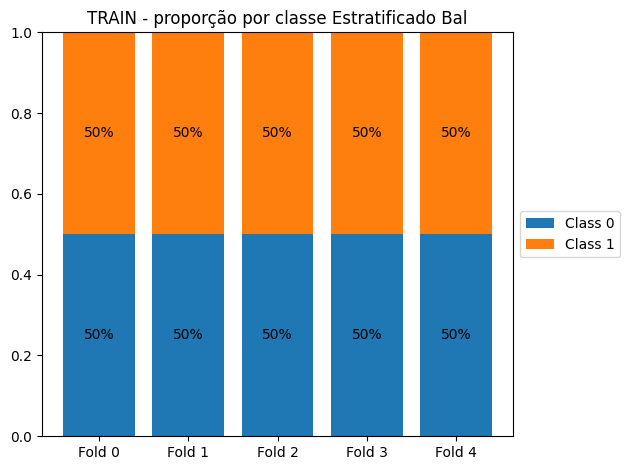

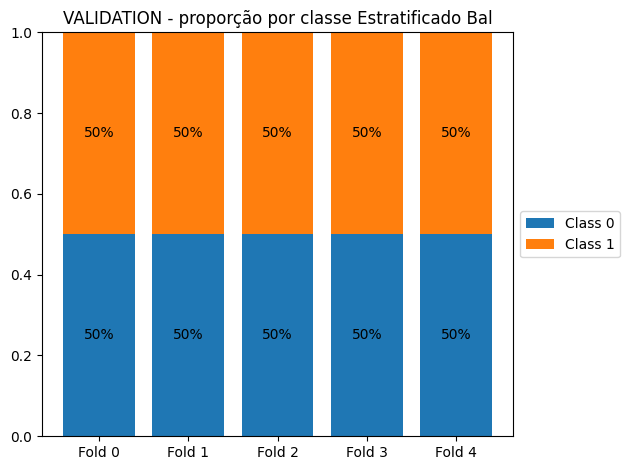

In [115]:
kfold = Kfold()

normal_folds = kfold.get_folds(X, y)
stratified_folds = kfold.get_stratified_folds(X, y)

kfold.plot_folds_distribution(normal_folds, "Tradicional Bal")
kfold.plot_folds_distribution(stratified_folds, "Estratificado Bal")

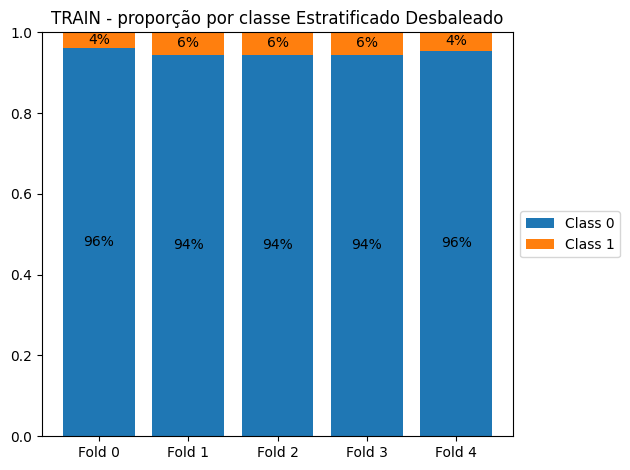

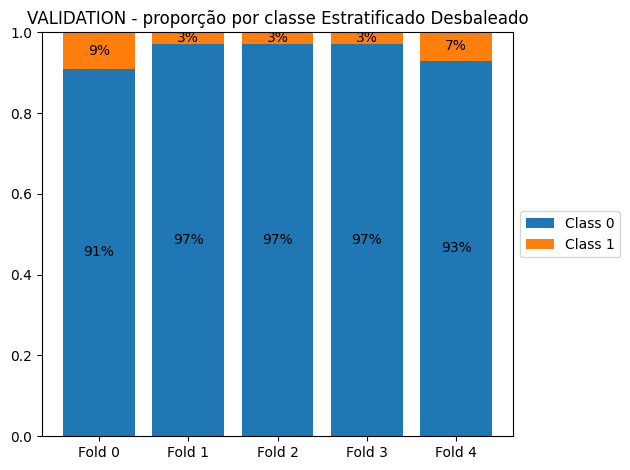

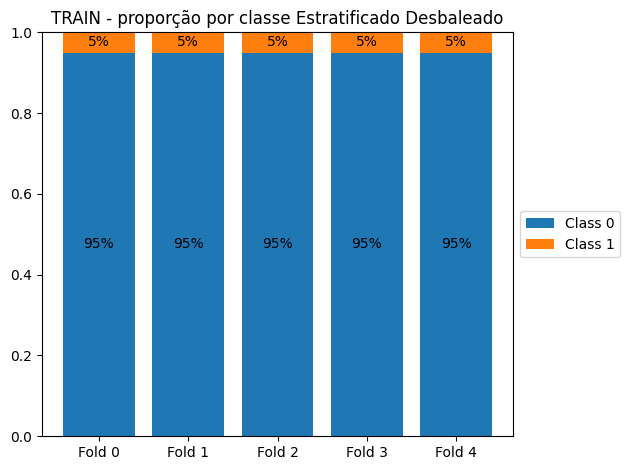

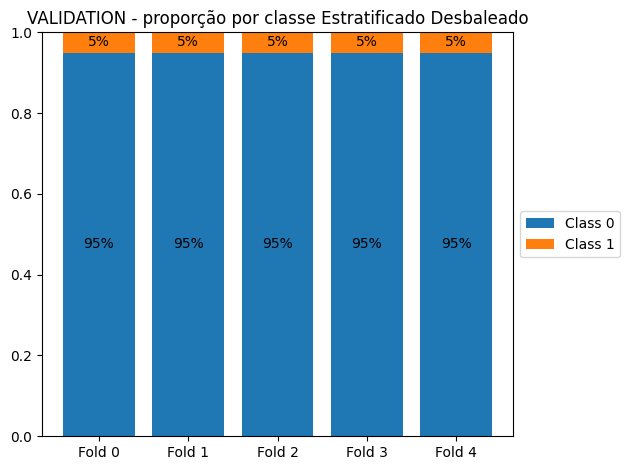

In [116]:
normal_folds_dbal = kfold.get_folds(X_bal, y_bal)
stratified_folds_dbal = kfold.get_stratified_folds(X_bal, y_bal)

kfold.plot_folds_distribution(normal_folds_dbal, "Estratificado Desbaleado")
kfold.plot_folds_distribution(stratified_folds_dbal, "Estratificado Desbaleado")

In [105]:
input_size = 2

seed = 42

topology = [input_size, 3, 1]

layers = [
    Layer(3, Neuron, tanh, d_tanh),
    Layer(1, Neuron, linear, d_linear)
]

nn = FFNeuralNetwork(topology, layers, rand_seed = seed)

nn.fit_by_folds(stratified_folds_dbal)


=== Fold 0 ===
Epoch 0, Erro: 0.12982682139676094
Epoch 100, Erro: 0.08089598837112613
Epoch 200, Erro: 0.07891038290066055
Epoch 300, Erro: 0.07747454422117585
Epoch 400, Erro: 0.08107171099072477
Erro médio (val): 0.0551
MSE (val): 0.0198
Acurácia (val): 0.9700

=== Fold 1 ===
Epoch 0, Erro: 0.1305017577111106
Epoch 100, Erro: 0.06942594525677799
Epoch 200, Erro: 0.06812413448501567
Epoch 300, Erro: 0.06841449722710351
Epoch 400, Erro: 0.06847426317926095
Erro médio (val): 0.0800
MSE (val): 0.0433
Acurácia (val): 0.9500

=== Fold 2 ===
Epoch 0, Erro: 0.12431241521451918
Epoch 100, Erro: 0.07132844016725576
Epoch 200, Erro: 0.07137742442089307
Epoch 300, Erro: 0.07231647943810068
Epoch 400, Erro: 0.07222210254185787
Erro médio (val): 0.0914
MSE (val): 0.0441
Acurácia (val): 0.9450

=== Fold 3 ===
Epoch 0, Erro: 0.12527919016154176
Epoch 100, Erro: 0.08159121686339336
Epoch 200, Erro: 0.08160410507602134
Epoch 300, Erro: 0.08023600379722183
Epoch 400, Erro: 0.07985715897078187
Erro mé